In [8]:
options(repr.plot.width = 10, repr.plot.height = 5, repr.plot.res = 200)

# 1- Load libraries

In [23]:
suppressPackageStartupMessages({
  library(tidyverse)
  library(tidymodels)
  library(readxl)
  library(janitor)
  library(plotly)
  library(corrr)
  library(corrplot)
  library(sjPlot)
  library(GGally)
  library(ggpubr)
  library(patchwork)
  library(agricolae)
  library(lmerTest)
  library(openxlsx)
})

# 2- Load data

In [4]:
data <- readxl::read_excel(
  "data/All Year 28 R Barley trial data.xlsx",
  sheet = "Overall_2",
  na = c("", "NA", "N/A", ".", "..", "-", "—")
) %>%
  clean_names() %>%
  filter(!(location == "Falher" & year == 2024)) %>%
  
  # Convert ALL character columns that should be numeric
  mutate(
    across(
      c(
        yield_adj_to_13_5_percent,
        yield_adj_to_13_5_percent_bu,
        avg_height_at_phys_maturity,
        lodging_index_1,
        lodging_index_2,
        lodging_index_3,
        tkw_avg,
        ndf_percent_dm,
        iv_d_ec_percent_dm,
        starch_percent_dm,
        test_weight_kg_h_l,
        protein_percent_dm,
        dtm,
        grain_moisture_percent
      ),
      ~ if (is.character(.x)) readr::parse_number(.x) else as.numeric(.x)
    )
  ) %>%
  
  mutate(
    cultivar = case_when(
      cultivar == "TR18647" ~ "AB_Hague",
      TRUE ~ cultivar
    )
  )
head(data)

year,location,plot,block,overall_trt_number,cultivar,pgr_trt_number,pgr_trt_name,emerge_avg_plants_m2,week_1_height,⋯,test_weight_kg_h_l,tkw_1_100_kernels,tkw_2_100_kernels,tkw_avg,tkw_avg_adjusted_to_13_5_percent_moisture,protein_percent_dm,starch_percent_dm,ndf_percent_dm,iv_d_ec_percent_dm,gross_return_yield_x_selling_rate_5_85
<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<chr>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2022,Vermilion,101,1,1,CDC_Austenson,1,No_PGR,139.1304,NA,⋯,66.13,4.5,4.7,46.0,46.84555,12.35137,61.80709,16.94731,3484.369,793.0985
2022,Vermilion,102,1,2,CDC_Austenson,2,M62.5_21-24,136.9565,NA,⋯,65.01,4.6,4.3,44.5,45.59578,12.16454,61.71610,16.99448,3492.453,744.2021
2022,Vermilion,103,1,3,CDC_Austenson,3,M62.5_30-32,158.6957,NA,⋯,69.78,4.8,4.9,48.5,49.55971,11.94270,60.99495,17.04296,3429.073,685.2741
2022,Vermilion,104,1,4,CDC_Austenson,4,M62.5_37,158.6957,NA,⋯,65.25,4.6,4.8,47.0,46.57075,11.90405,61.71217,16.27136,3398.832,1029.5546
2022,Vermilion,105,1,5,CDC_Austenson,5,M125_30-32,210.8696,NA,⋯,66.56,4.8,4.8,48.0,48.57156,12.28261,61.19565,17.06522,3464.130,809.3649
2022,Vermilion,106,1,6,CDC_Austenson,6,M125_37,182.6087,NA,⋯,67.16,4.6,4.6,46.0,46.64879,12.39285,60.91529,16.46905,3407.598,913.5992


# EDA

In [5]:
skimr::skim(data) %>% print()

── Data Summary ────────────────────────
                           Values
Name                       data  
Number of rows             864   
Number of columns          41    
_______________________          
Column type frequency:           
  character                4     
  numeric                  36    
  POSIXct                  1     
________________________         
Group variables            None  

── Variable type: character ────────────────────────────────────────────────────
  skim_variable        n_missing complete_rate min max empty n_unique whitespace
1 location                     0         1       6  10     0        3          0
2 cultivar                     0         1       4  13     0        3          0
3 pgr_trt_name                 0         1       6  25     0        9          0
4 booting_date_of_plot       325         0.624   2   6     0       12          0

── Variable type: numeric ──────────────────────────────────────────────────────
   skim_variable

In [6]:
# Custom theme
theme_nice <- function(){
  theme_bw()+
  theme(axis.title = element_text(size = 20),
        axis.text = element_text(size = 20),
        plot.title = element_text(size = 20),
        strip.text = element_text(size = 18))
}

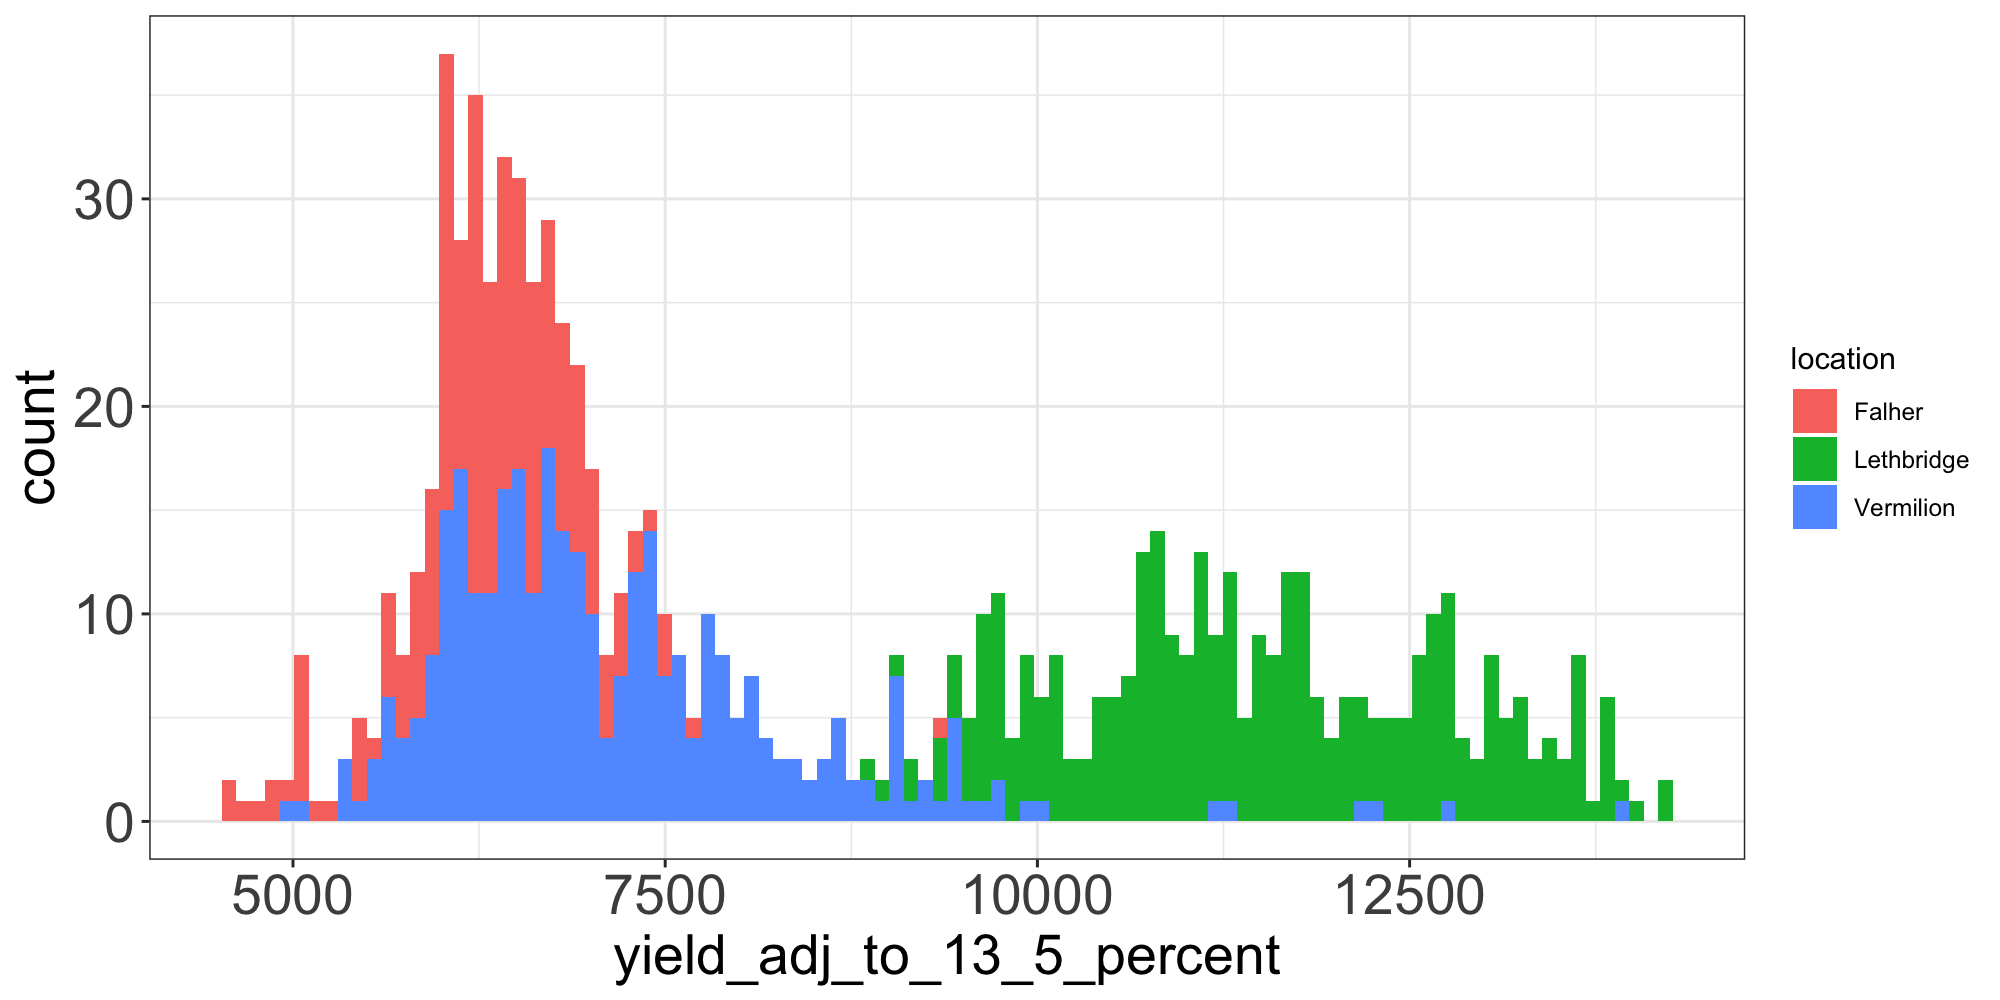

In [10]:
data %>% 
drop_na(yield_adj_to_13_5_percent)%>%
  ggplot(aes(yield_adj_to_13_5_percent, fill = location))+
  geom_histogram(bins = 100)+
theme_nice()

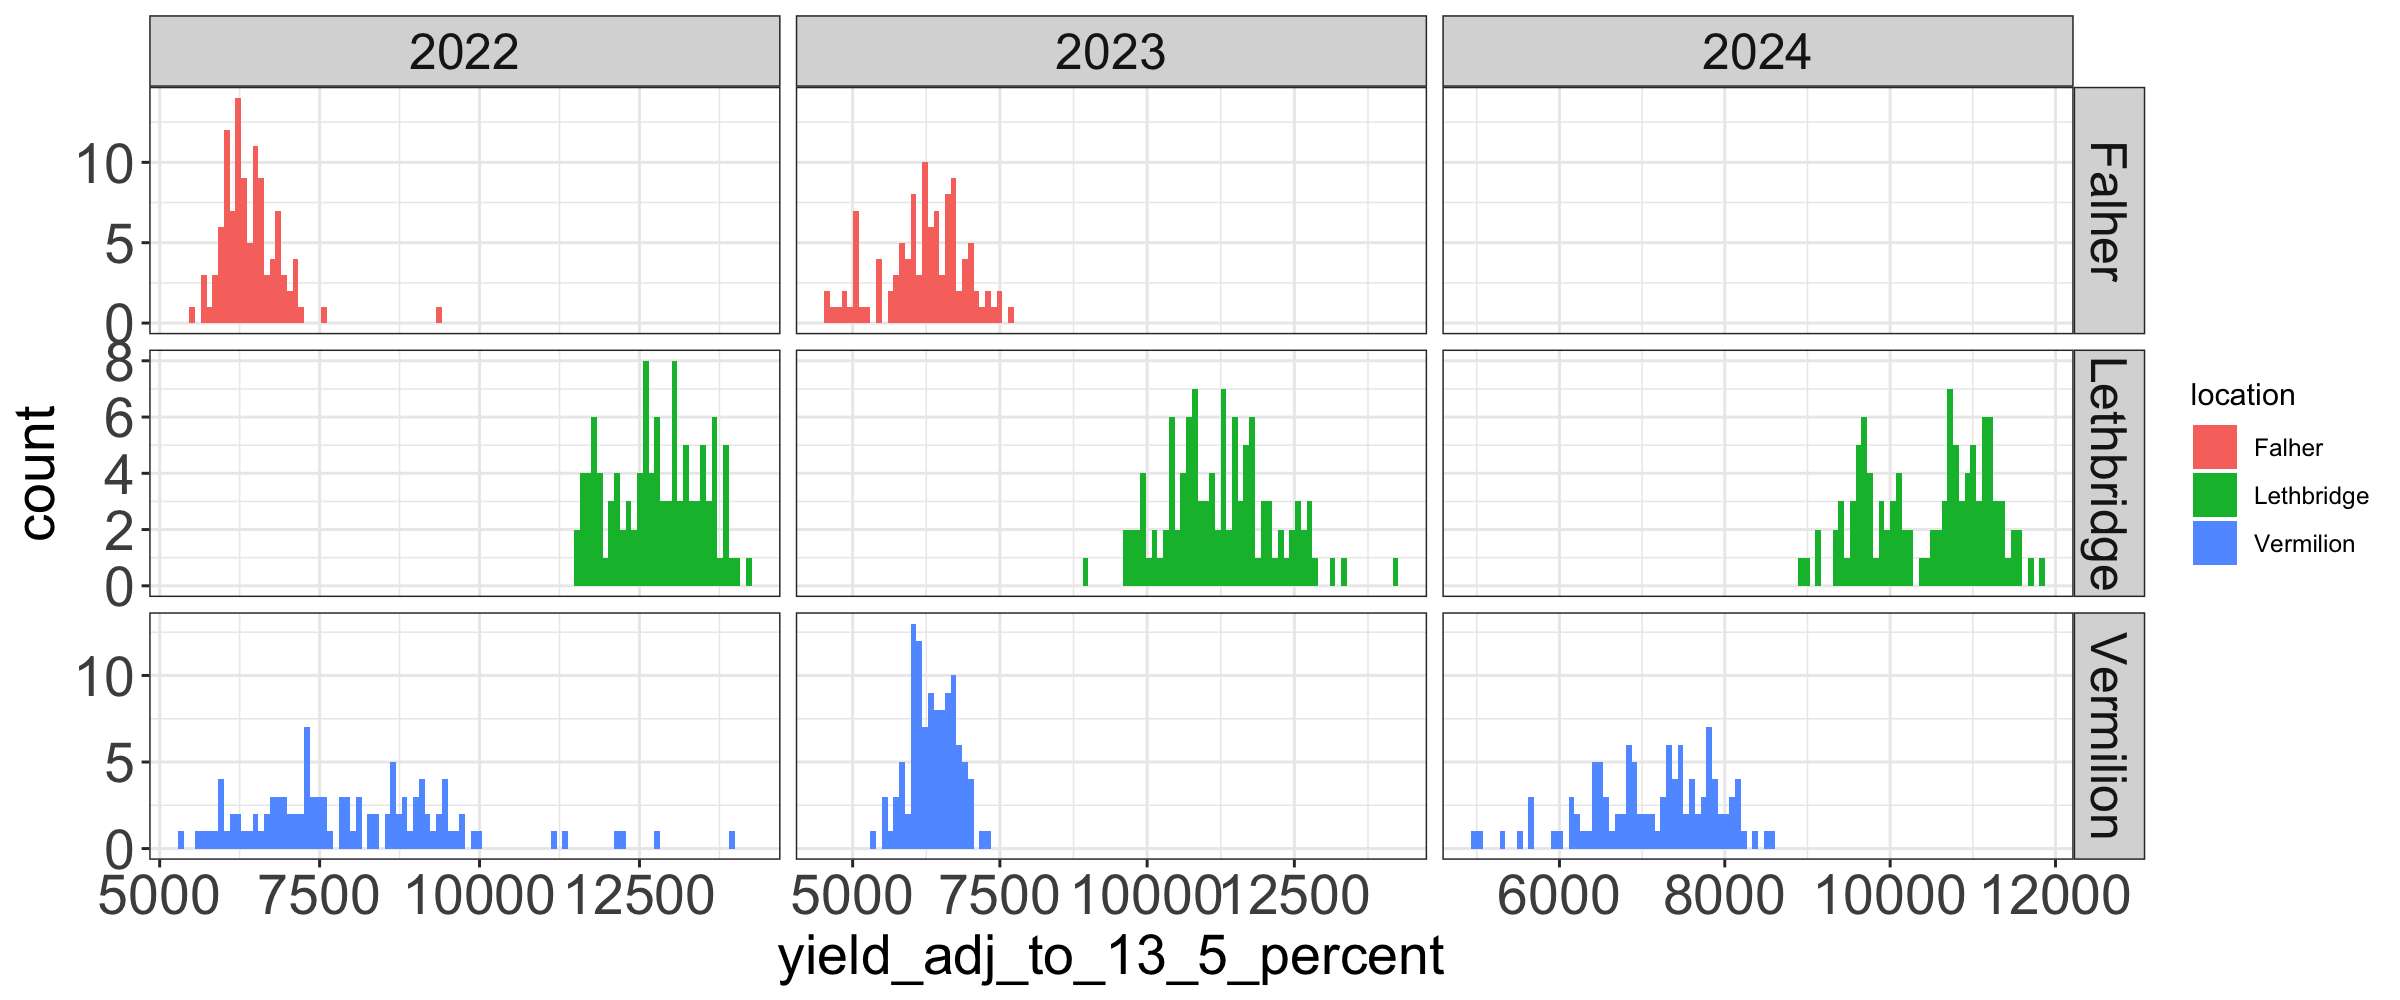

In [11]:
options(repr.plot.width = 12, repr.plot.height = 5, repr.plot.res = 200)
data %>% 
drop_na(yield_adj_to_13_5_percent)%>%
  ggplot(aes(yield_adj_to_13_5_percent, fill = location))+
  geom_histogram(bins = 100)+
  #geom_density(aes(alpha = 0.3))+
  facet_grid(location ~ year, scales = "free")+
theme_nice()

In [12]:
cleaned_data_imputed <- readRDS("data/cleaned_data_imputed.rds")

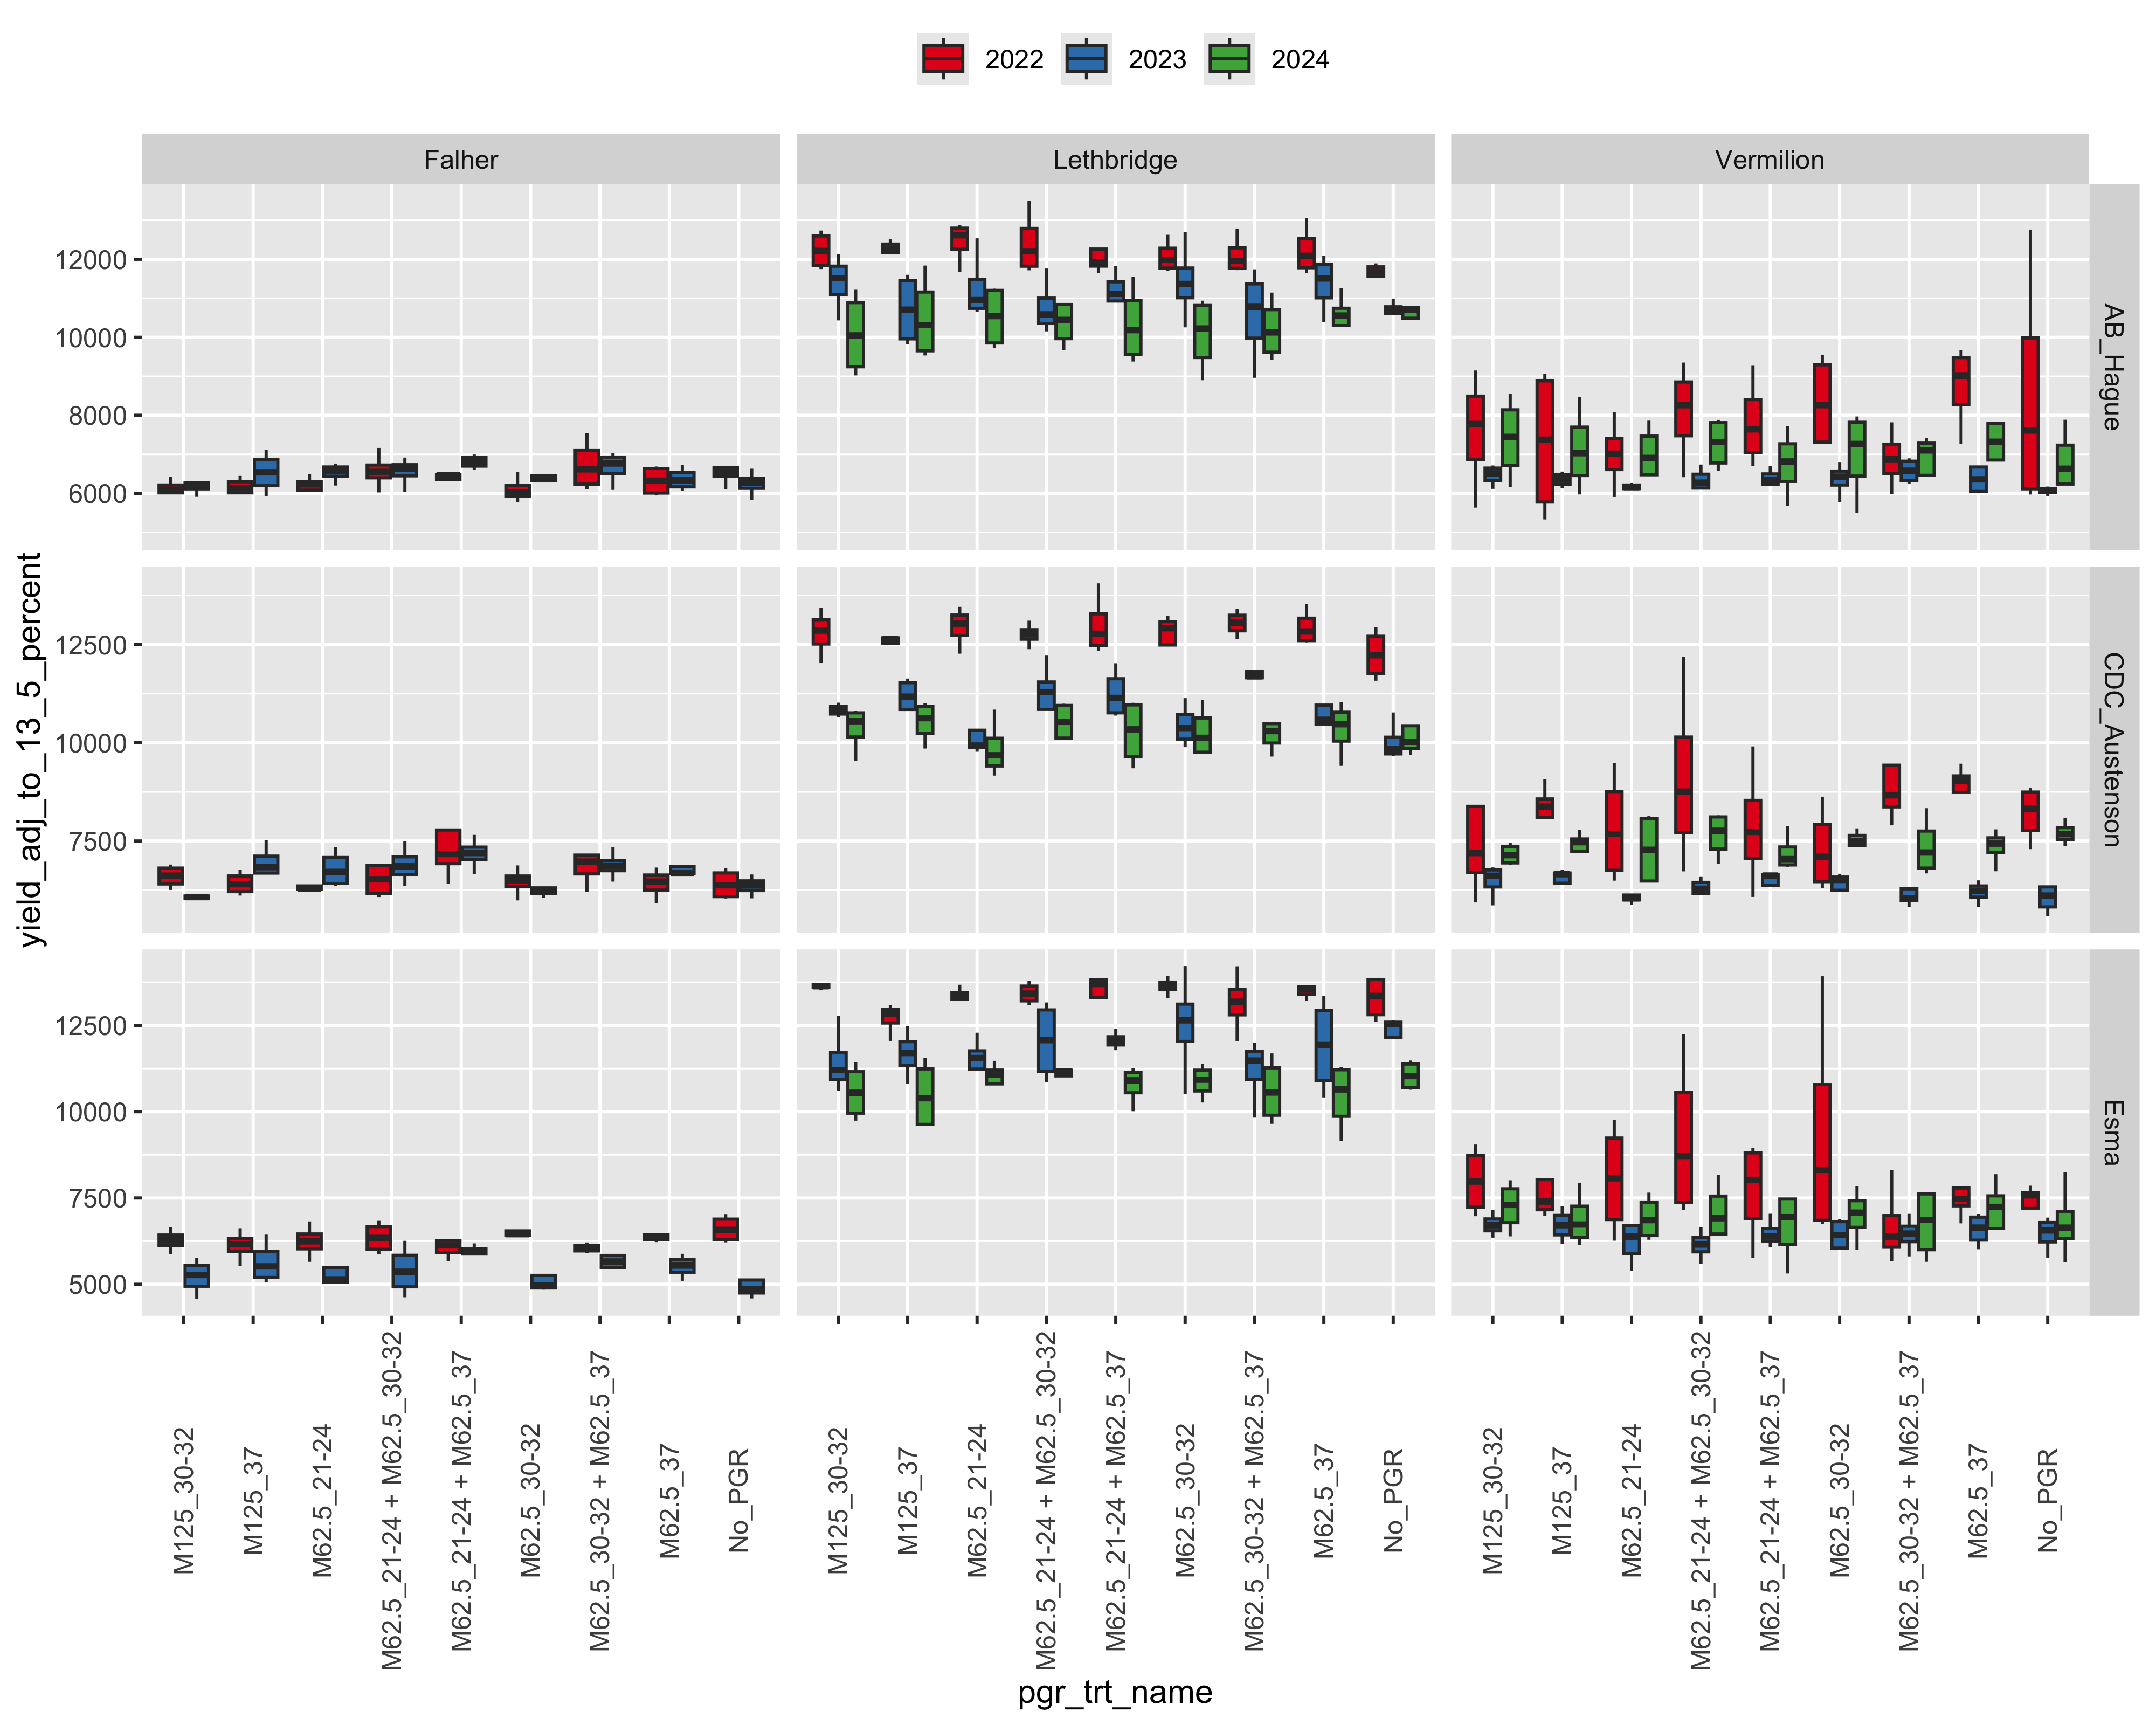

In [13]:
options(repr.plot.width = 10, repr.plot.height = 8, repr.plot.res = 400)
cleaned_data_imputed %>% 
drop_na(yield_adj_to_13_5_percent)%>%
  ggplot(aes(pgr_trt_name, yield_adj_to_13_5_percent, fill = as.factor(year)))+
  geom_boxplot(outlier.shape = NA)+
facet_grid(cultivar ~ location, scales = "free_y")+
 scale_fill_brewer(palette = "Set1") +
theme(axis.text.x = element_text(angle = 90, vjust = 0.5),
     legend.position = "top")+
labs(fill = "")

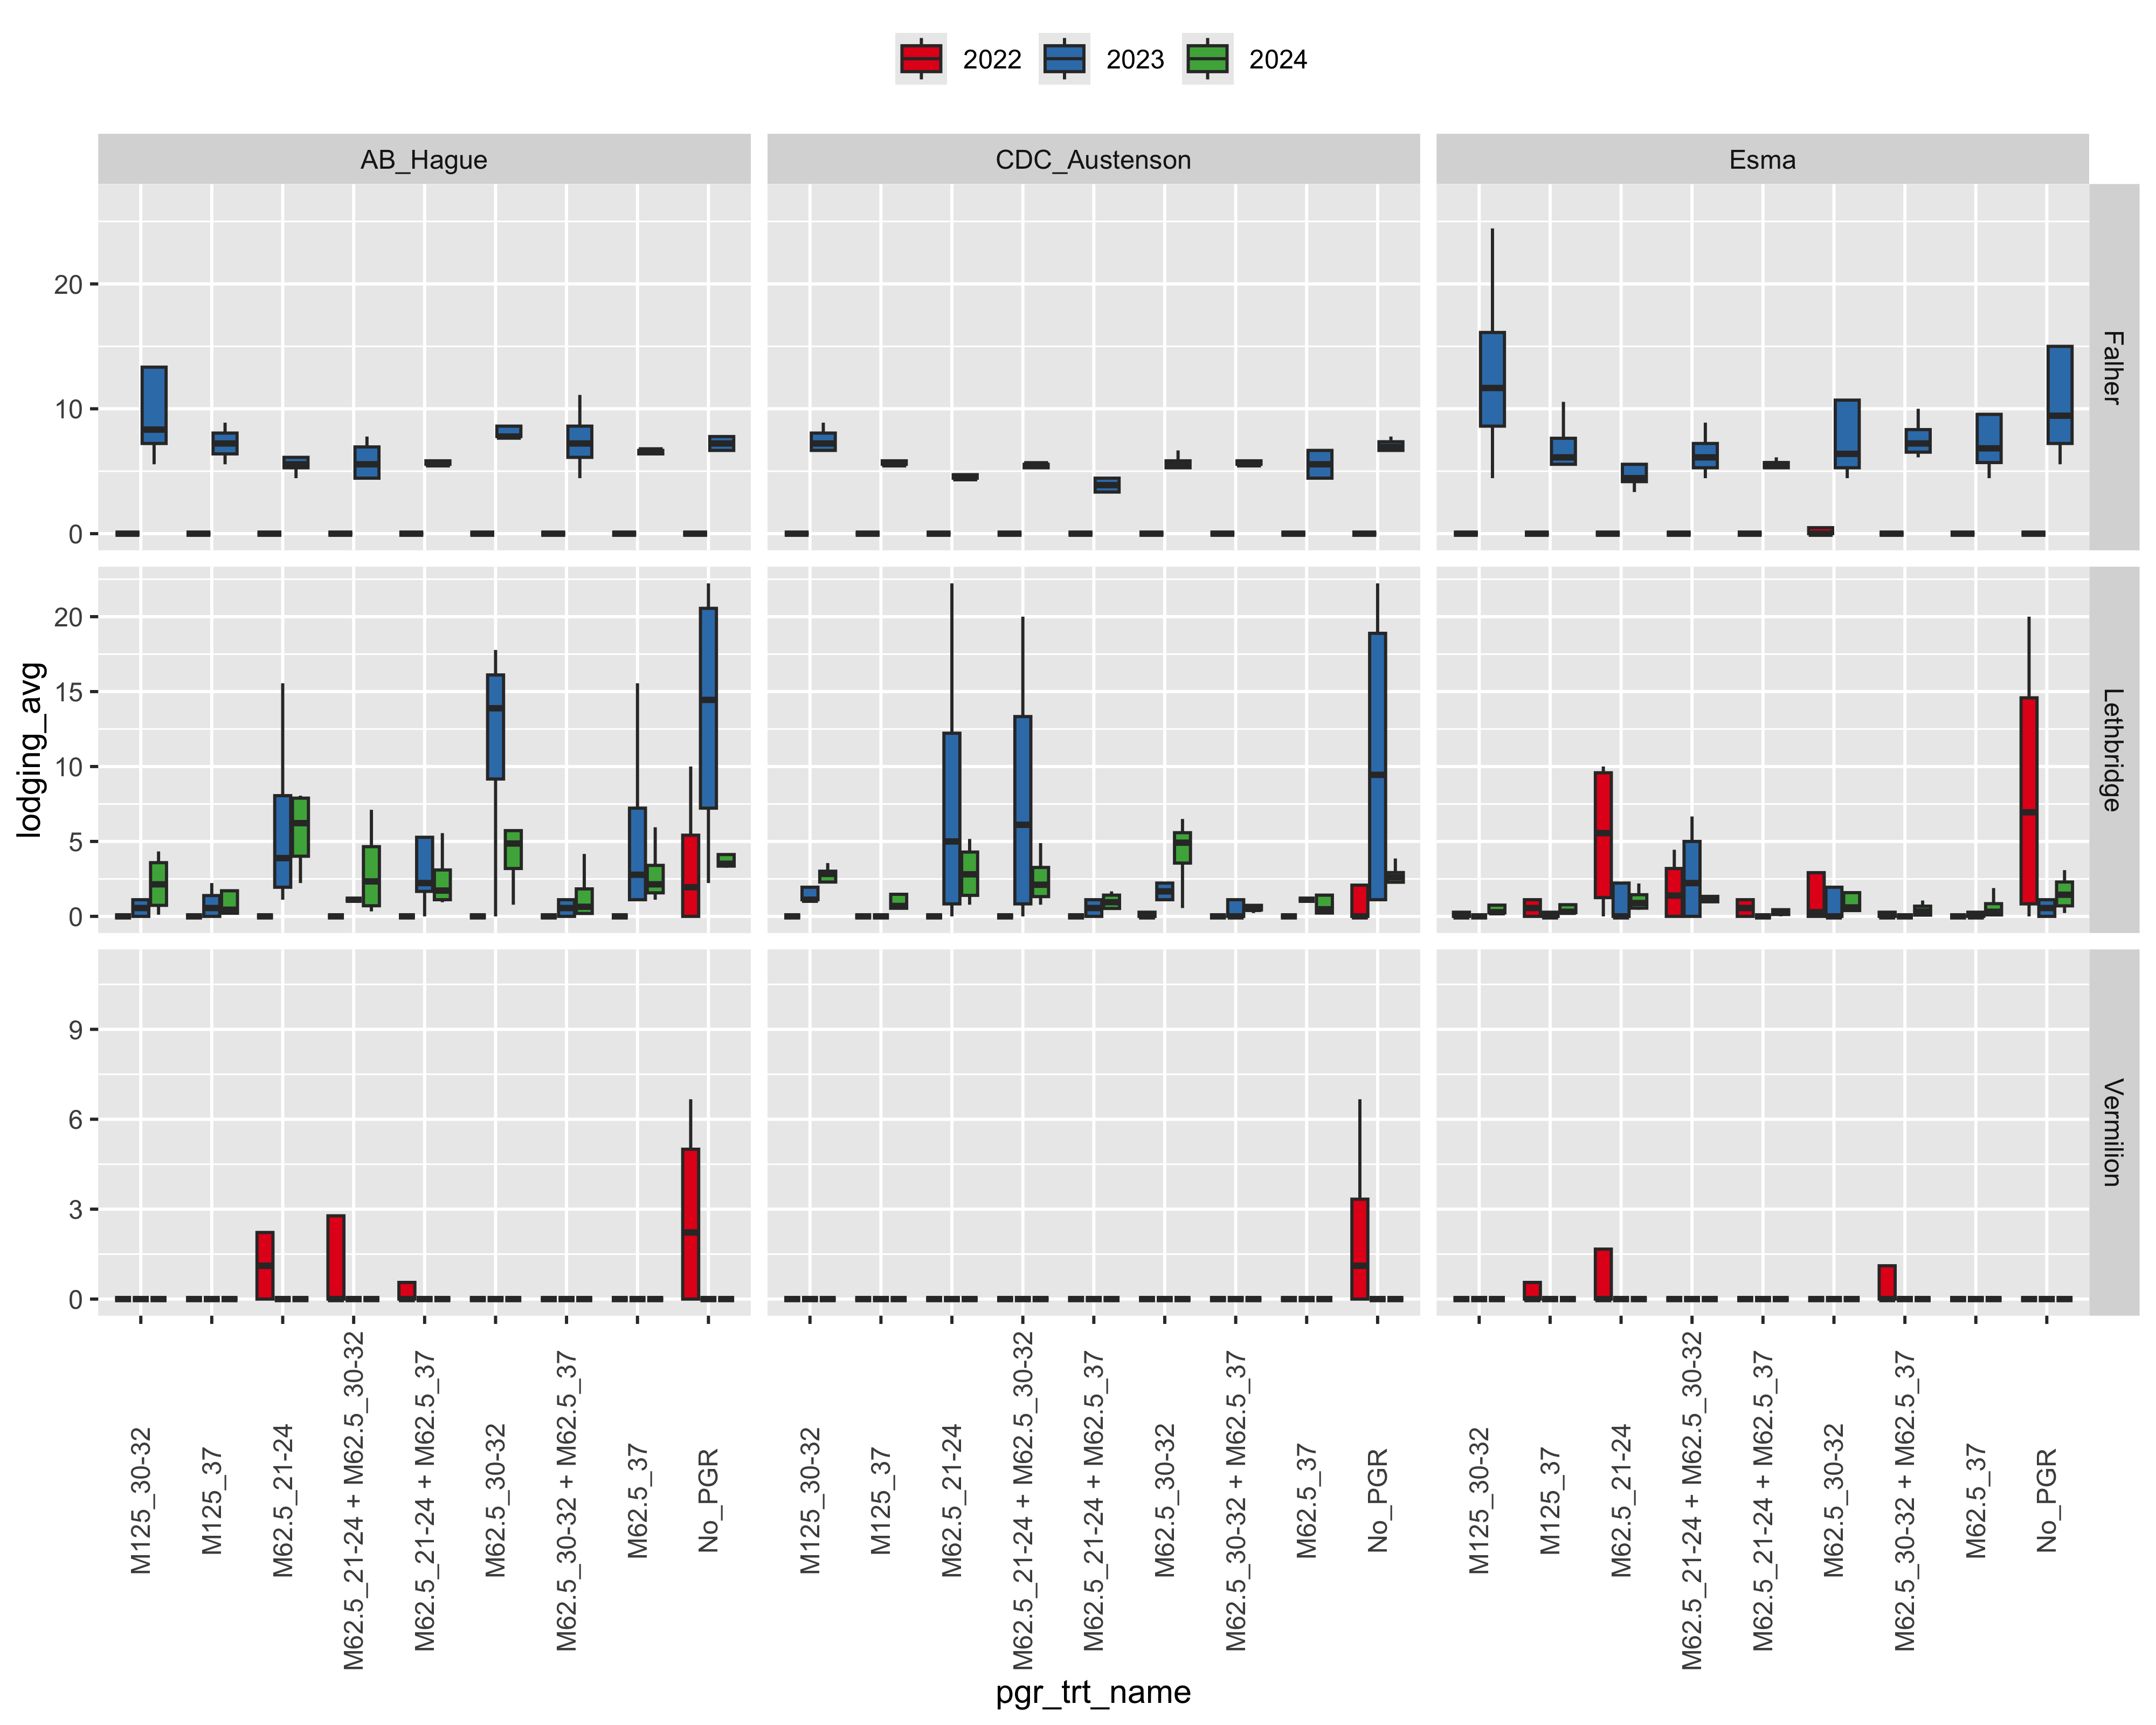

In [14]:
options(repr.plot.width = 10, repr.plot.height = 8, repr.plot.res = 400)
cleaned_data_imputed %>% 
  ggplot(aes(pgr_trt_name, lodging_avg, fill = as.factor(year)))+
  geom_boxplot(outlier.shape = NA)+
facet_grid(location ~ cultivar, scales = "free_y")+
 scale_fill_brewer(palette = "Set1") +
theme(axis.text.x = element_text(angle = 90, vjust = 0.5),
     legend.position = "top")+
labs(fill = "")

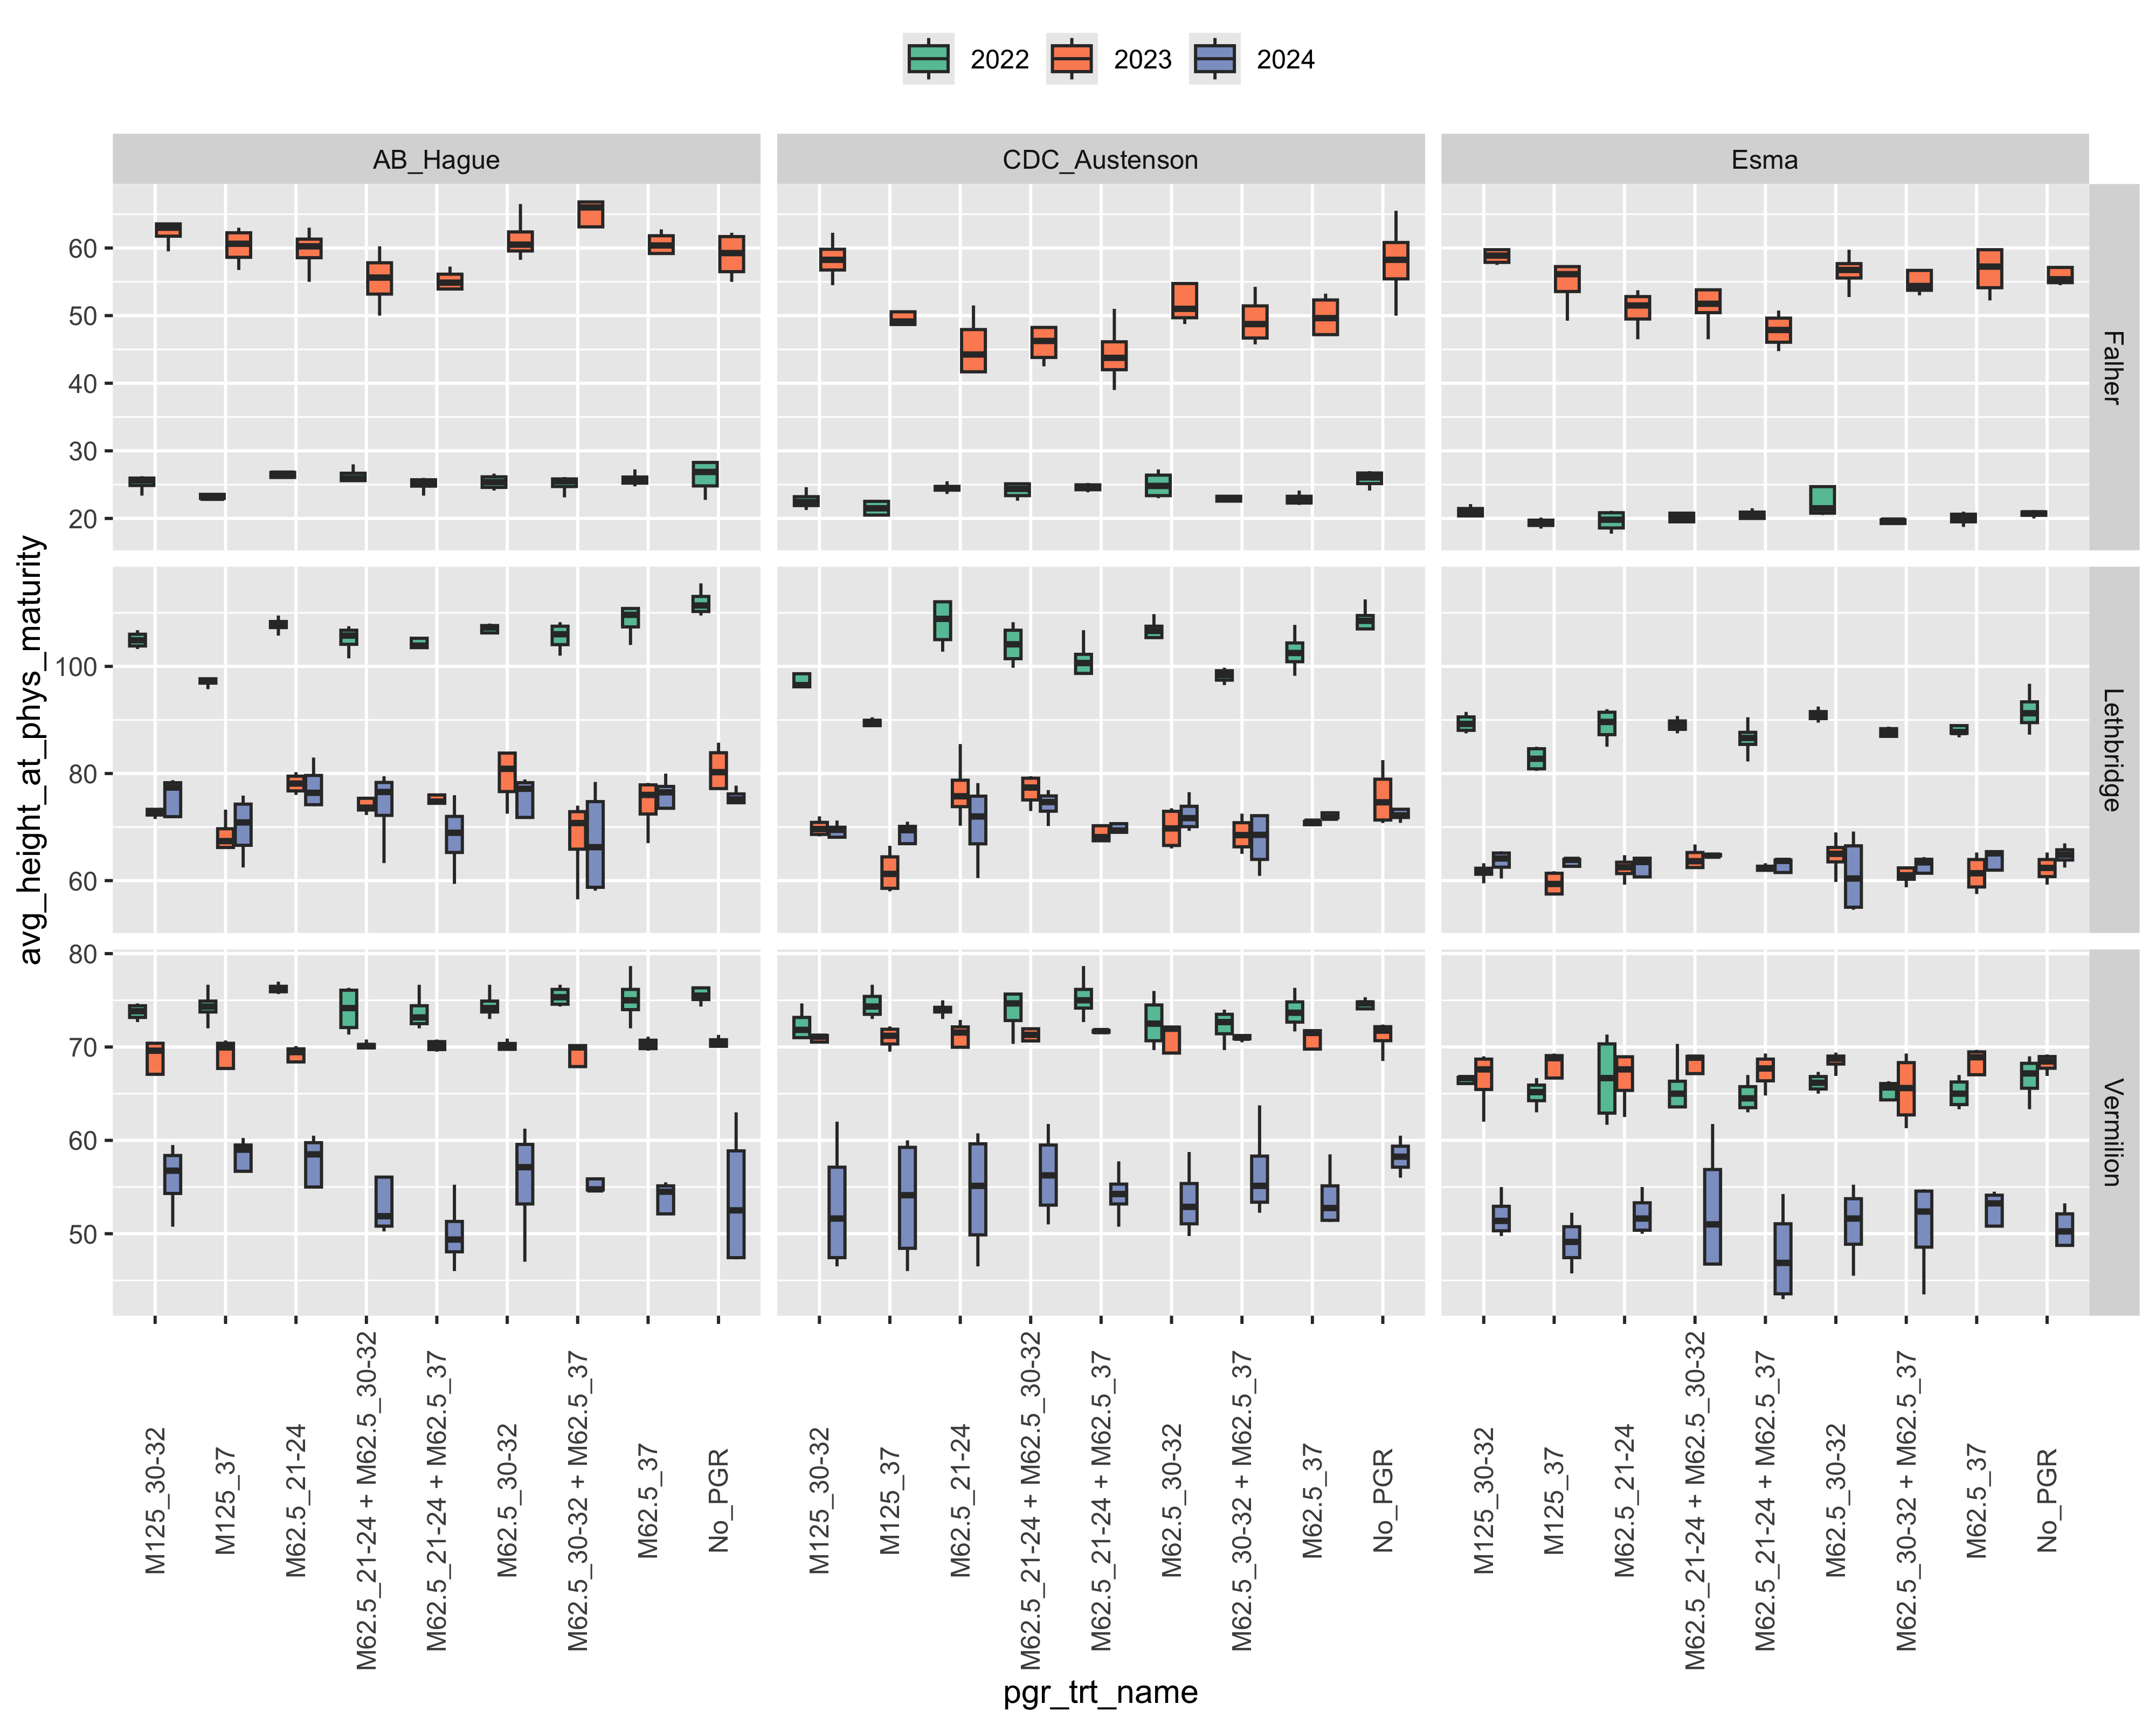

In [15]:
options(repr.plot.width = 10, repr.plot.height = 8, repr.plot.res = 400)
cleaned_data_imputed %>% 
  ggplot(aes(pgr_trt_name, avg_height_at_phys_maturity, fill = as.factor(year)))+
  geom_boxplot(outlier.shape = NA)+
facet_grid(location ~ cultivar, scales = "free_y")+
 scale_fill_brewer(palette = "Set2") +
theme(axis.text.x = element_text(angle = 90, vjust = 0.5),
     legend.position = "top")+
labs(fill = "")

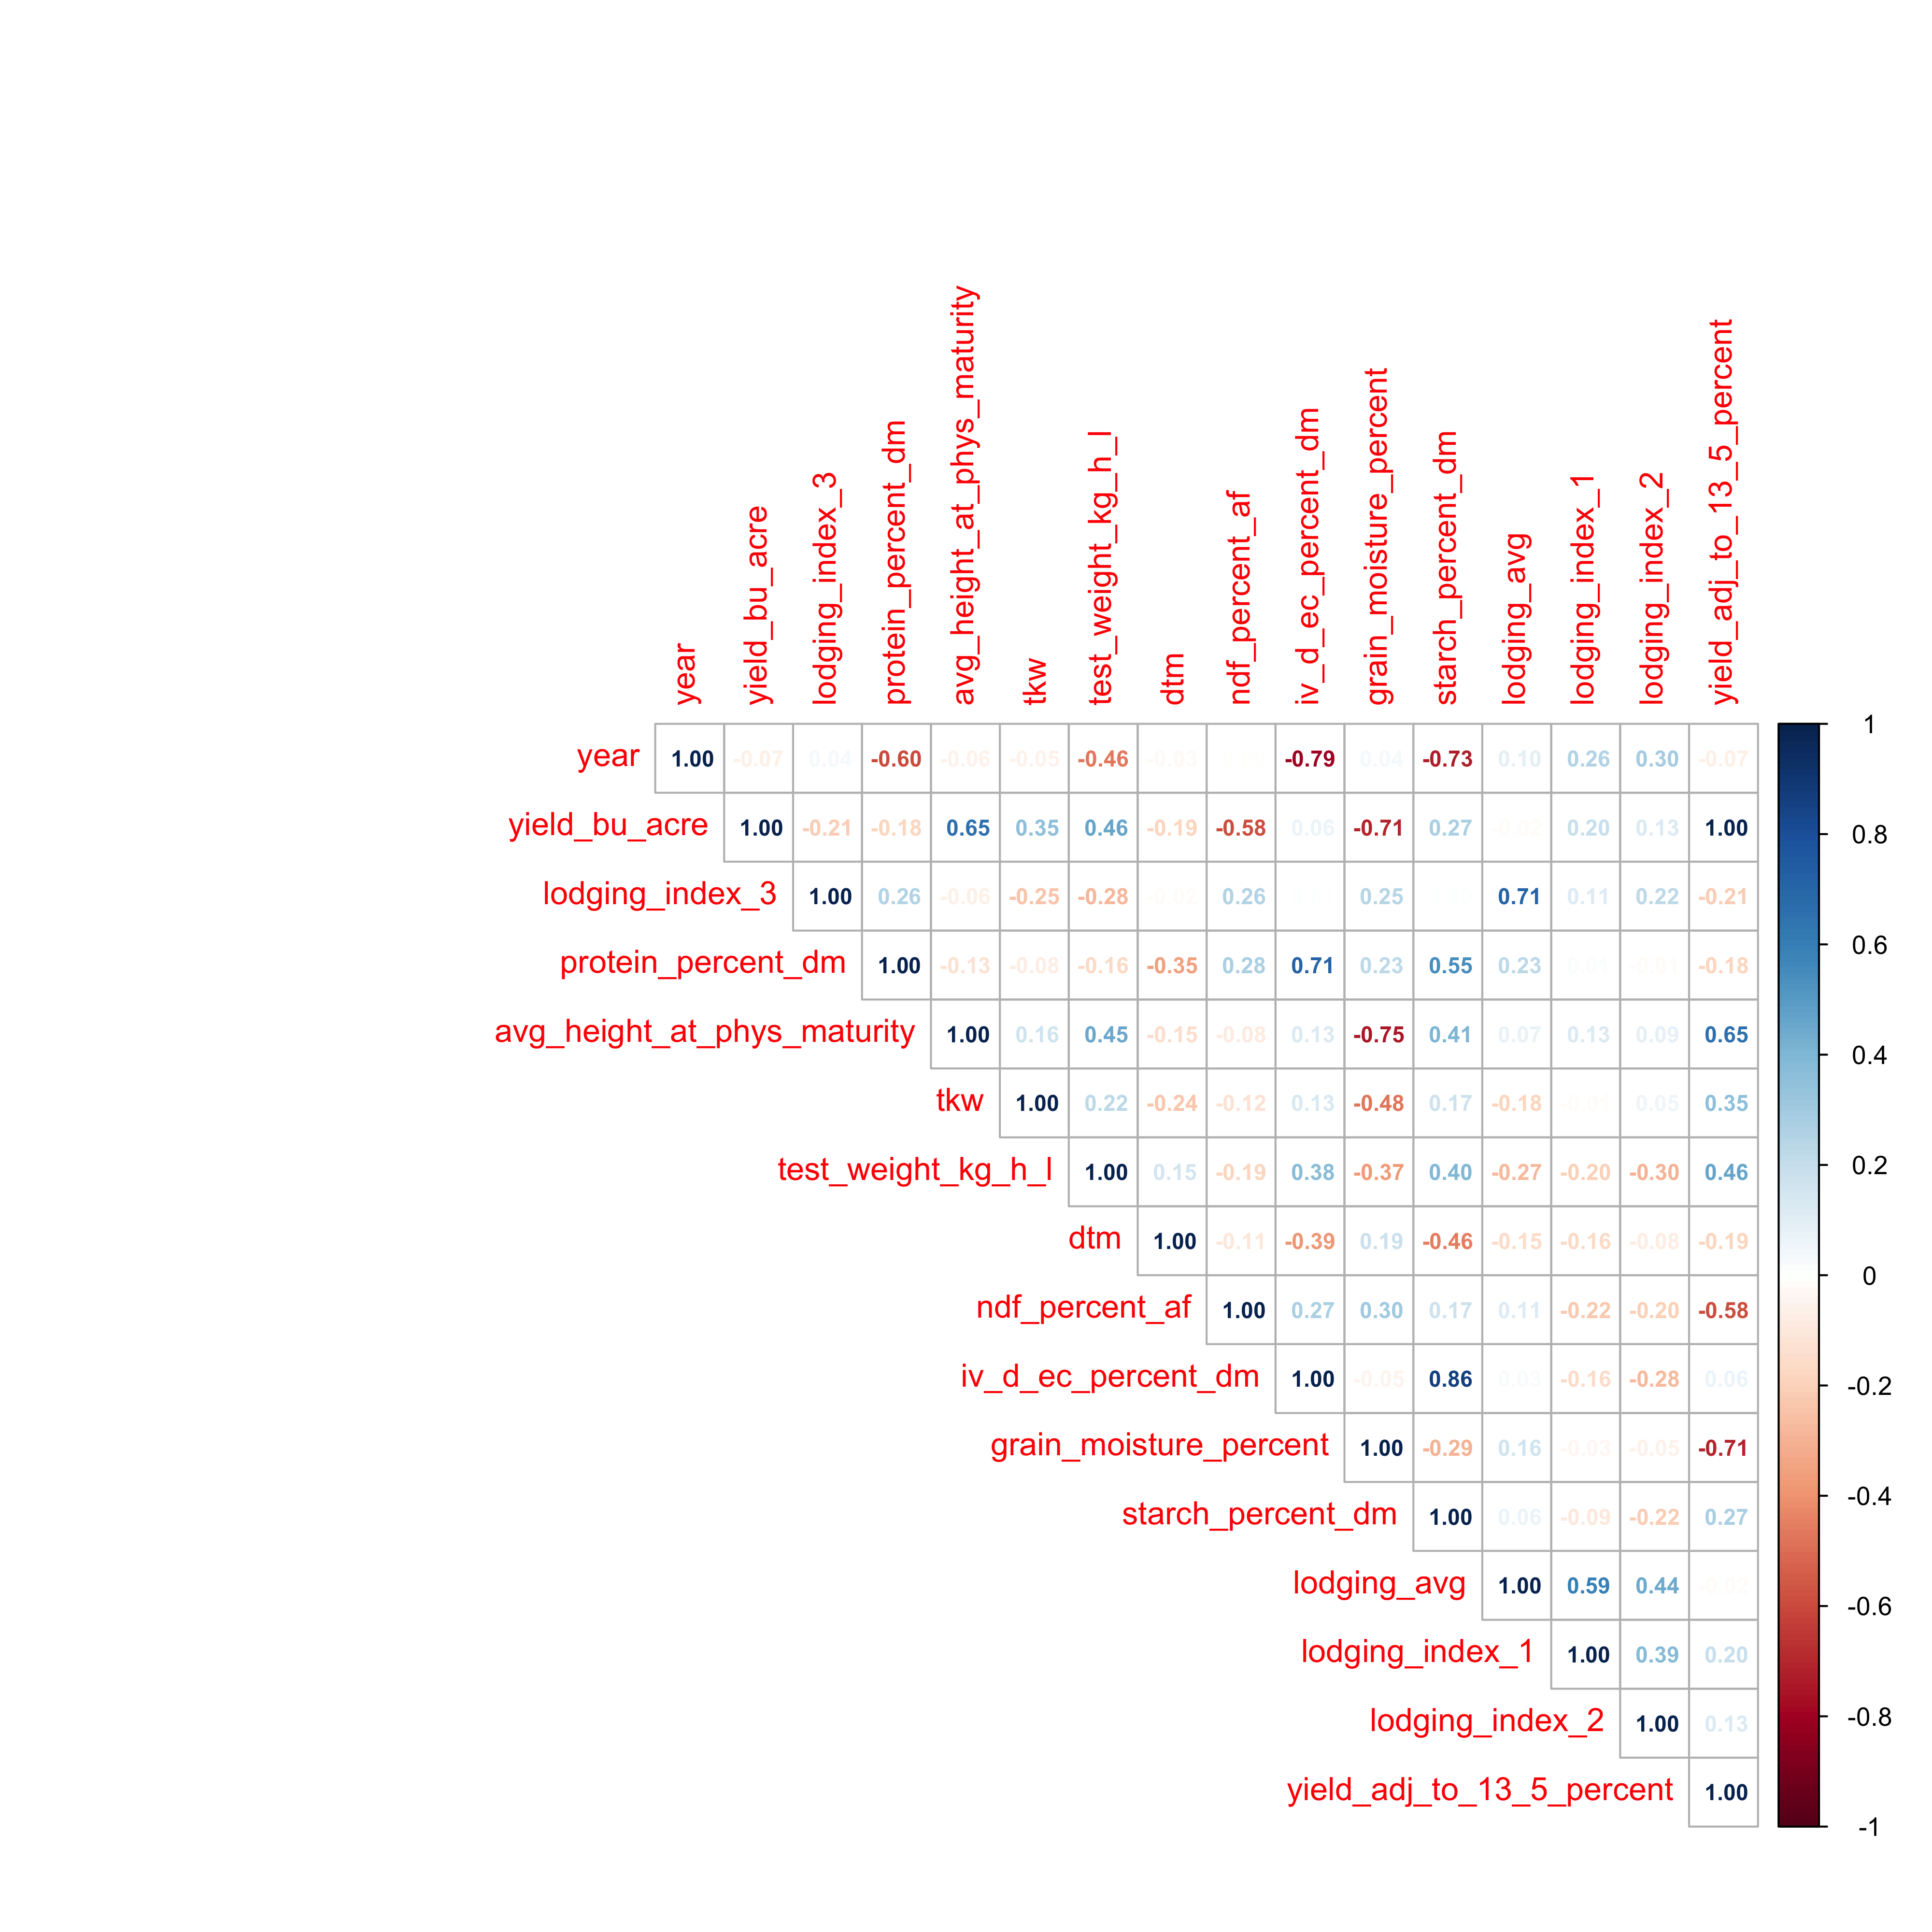

In [26]:
options(repr.plot.width = 10, repr.plot.height = 10, repr.plot.res = 400)
data_corr <- cleaned_data_imputed %>%
  select(where(is.numeric))
corrplot(cor(data_corr),
  method = "number",
  type = "upper", # show only upper side
         number.cex = 0.7 
)